In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.utils import to_categorical

In [11]:
from sklearn.datasets import load_iris
import pandas as pd

iris_data = load_iris()

df = pd.DataFrame(iris_data.data, columns=iris_data.feature_names)
df['target'] = iris_data.target

df['Species'] = df['target'].map({
    0: 'Iris-setosa',
    1: 'Iris-versicolor',
    2: 'Iris-virginica'
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,Species
0,5.1,3.5,1.4,0.2,0,Iris-setosa
1,4.9,3.0,1.4,0.2,0,Iris-setosa
2,4.7,3.2,1.3,0.2,0,Iris-setosa
3,4.6,3.1,1.5,0.2,0,Iris-setosa
4,5.0,3.6,1.4,0.2,0,Iris-setosa


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   Species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


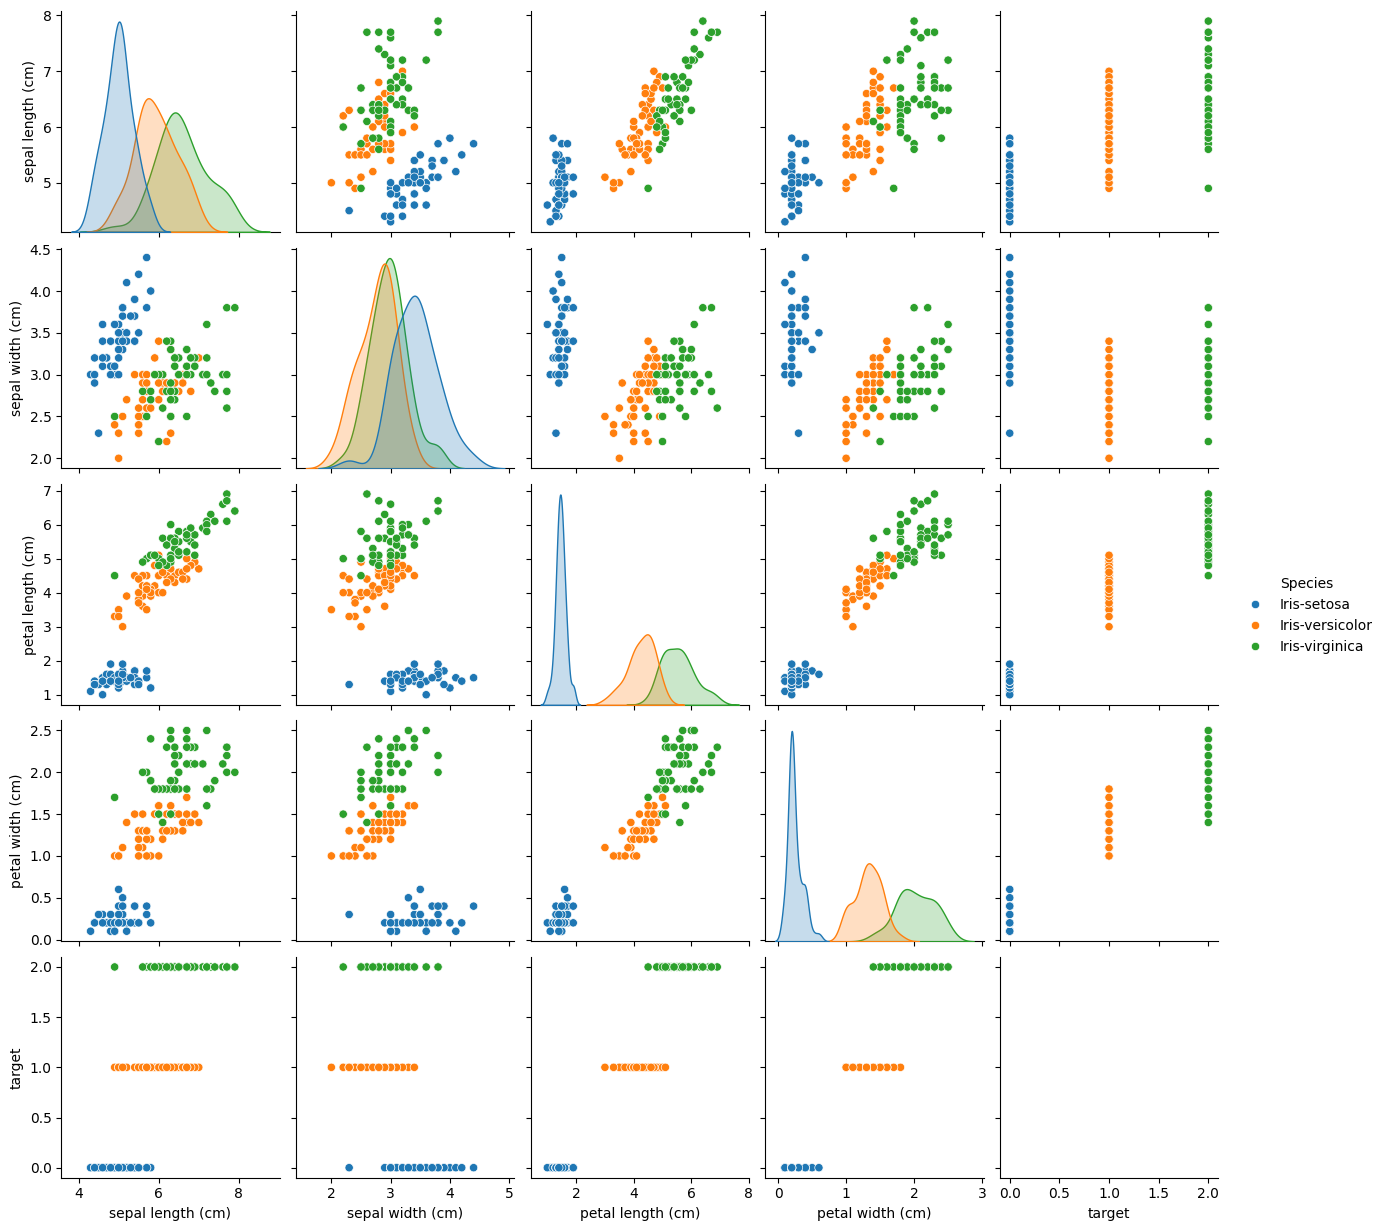

In [14]:
sns.pairplot(df, hue = 'Species')

In [16]:
df.drop(columns = ['target'], axis=1 ,inplace = True)

In [17]:
X = df.drop(columns = ['Species'], axis = 1)
y = df['Species']

In [18]:
encoder = LabelEncoder()
y_enc = encoder.fit_transform(y)
y_enc

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size = 0.20, random_state = 42)

In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
perceptron = Perceptron(max_iter = 1000, random_state = 42)
perceptron.fit(X_train_scaled, y_train)

Perceptron(random_state=42)

In [24]:
y_pred_per = perceptron.predict(X_test_scaled)

In [25]:
accuracy_score(y_test, y_pred_per)

0.9333333333333333

In [26]:
 print(classification_report(y_test, y_pred_per))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.82      1.00      0.90         9
           2       1.00      0.82      0.90        11

    accuracy                           0.93        30
   macro avg       0.94      0.94      0.93        30
weighted avg       0.95      0.93      0.93        30



In [28]:
y_train_cat = to_categorical(y_train, num_classes = 3)
y_test_cat = to_categorical(y_test, num_classes = 3)

In [29]:
model = Sequential({
    Dense(16, input_dim = 4, activation = 'relu'),
    Dense(8, activation = 'relu'),
    Dense(3, activation = 'softmax')
})

In [30]:
model.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

In [31]:
history = model.fit(X_train_scaled, y_train_cat,
                    epochs = 100,
                    batch_size = 8,
                    validation_split = 0.2,
                    verbose = 1)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.0312 - loss: 1.2773 - val_accuracy: 0.0417 - val_loss: 1.2013
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1354 - loss: 1.1530 - val_accuracy: 0.2083 - val_loss: 1.1091
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3646 - loss: 1.0555 - val_accuracy: 0.5417 - val_loss: 1.0291
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6458 - loss: 0.9729 - val_accuracy: 0.8333 - val_loss: 0.9645
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7708 - loss: 0.9047 - val_accuracy: 0.8750 - val_loss: 0.9067
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8333 - loss: 0.8421 - val_accuracy: 0.9167 - val_loss: 0.8566
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8854 - loss: 0.7879 - val_accuracy: 0.9167 - val_loss: 0.8120
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8958 - loss: 0.7382 - val_accuracy: 0.9167 

In [33]:
loss, acc = model.evaluate(X_test_scaled, y_test_cat, verbose = 1)
print('Test Loss:', loss)
print('Test Accuracy:', acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 1.0000 - loss: 0.0649
Test Loss: 0.06485050171613693
Test Accuracy: 1.0


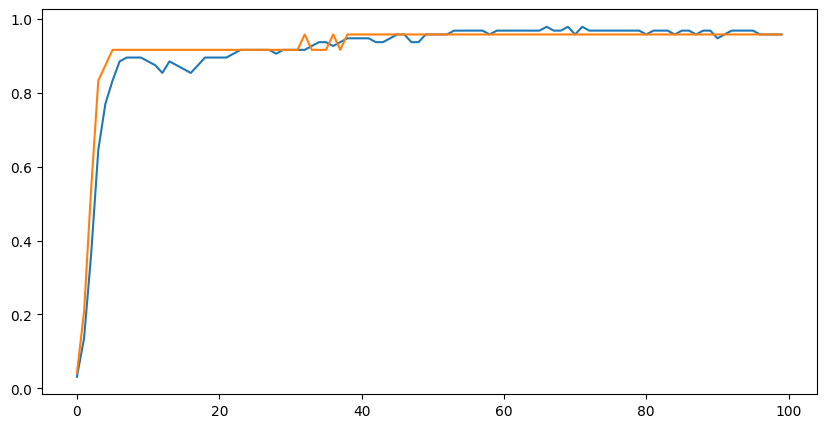

In [35]:
plt.figure(figsize = (10, 5))
plt.plot(history.history['accuracy'], label = 'train accuracy')
plt.plot(history.history['val_accuracy'], label = 'validation accuracy')
plt.show()